# Paper §5.1 — Layer-wise attention peaks

Reproduces the per-`(model, dataset)` attention peak layer table that underpins paper §5.1 (Per-model peak heterogeneity) and Appendix G.

**Spec source-of-truth.** `docs/paper/emnlp_outline_ko.md` — §5.1 (Layer-wise probes).

This notebook drives the heavy inference stages by `subprocess`-invoking
the existing sharded drivers in `scripts/`. The `RUN_INFERENCE = False`
toggle below lets a reviewer read the entire pipeline without GPU
access. Full reproduction targets the **8 × H200** cluster and uses
`--gpus 0,1,2,3,4,5,6,7` end-to-end.


## 1 · Setup — paths, GPU sharding, subprocess helper

In [1]:
from __future__ import annotations
import json
import os
import shlex
import subprocess
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_main_worktree() -> Path:
    # Gitignored artifacts (inputs/, outputs/, docs/insights/_data/) live in
    # the main worktree even when this notebook runs from a linked worktree.
    common = subprocess.check_output(
        ["git", "rev-parse", "--git-common-dir"], cwd=Path.cwd(), text=True
    ).strip()
    return Path(common).resolve().parent


def find_worktree_root() -> Path:
    # Current worktree's working tree top (== main when not in a linked worktree).
    return Path(subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"], cwd=Path.cwd(), text=True
    ).strip()).resolve()


MAIN     = find_main_worktree()
WORKTREE = find_worktree_root()

# Outputs live under MAIN (gitignored); figures land under WORKTREE so they ride the active branch.
# Scripts + configs come from WORKTREE so the active branch's edits are used
# (subprocess invocations would otherwise hit the stale main-worktree copies
# until the active PR merges).
SCRIPTS    = WORKTREE / "scripts"
CONFIGS    = WORKTREE / "configs"
DATA_DIR   = MAIN / "docs" / "insights" / "_data"
PRED_ROOT  = MAIN / "outputs" / "paper" / "cross_model_cross_dataset" / "predictions"

# §5.2 e6_steering input root selection (same toggle as §5.1 above):
#   - RUN_INFERENCE=False: read pre-existing sweep dirs from legacy
#     `outputs/e6_steering/` (the aggregators have always filtered by
#     subdirectory name, so the legacy tree won't pollute results even
#     when read-only).
#   - RUN_INFERENCE=True: write new calibrate / sweep dirs to an isolated
#     tree so this run doesn't commingle with the legacy pool.
E6_ROOT_LEGACY = MAIN / "outputs" / "e6_steering"
E6_ROOT_FRESH  = MAIN / "outputs" / "paper" / "section_5_e6_steering"

# §5.1 attention input root selection:
#   - RUN_INFERENCE=False: read pre-existing bbox-with runs from
#     legacy outputs/attention_analysis/ (the docstring header in
#     `extract_attention_mass.py` confirms each model has multiple
#     timestamped runs carrying `image_anchor_digit`; the analyzer
#     auto-skips bbox-less records via field-presence check).
#   - RUN_INFERENCE=True: write new runs to a fresh isolated tree so
#     they do not commingle with the legacy pool.
ATT_ROOT_LEGACY = MAIN / "outputs" / "attention_analysis"
ATT_ROOT_FRESH  = MAIN / "outputs" / "paper" / "section_5_attention"
PEAKS_CSV       = MAIN / "outputs" / "paper" / "section_5_attention" / "_data" / "cross_dataset_peaks.csv"
BBOX_FILE       = MAIN / "inputs" / "irrelevant_number_bboxes.json"

ATT_ROOT_FRESH.mkdir(parents=True, exist_ok=True)
PEAKS_CSV.parent.mkdir(parents=True, exist_ok=True)
assert BBOX_FILE.exists(), f"missing digit-pixel bbox JSON: {BBOX_FILE}"

PDF_OUT = MAIN     / "outputs" / "paper" / "section_5_figures"
PNG_OUT = WORKTREE / "docs"    / "figures"
PDF_OUT.mkdir(parents=True, exist_ok=True)
PNG_OUT.mkdir(parents=True, exist_ok=True)

GPUS = os.environ.get("VLM_ANCHOR_GPUS", "0,1,2,3,4,5,6,7")  # 8 GPUs by default
RUN_INFERENCE = False  # set True to invoke the heavy sharded drivers.

# Pick the attention + e6_steering input roots based on the toggle
# (resolved AFTER RUN_INFERENCE).
ATT_ROOT = ATT_ROOT_FRESH if RUN_INFERENCE else ATT_ROOT_LEGACY
E6_ROOT  = E6_ROOT_FRESH  if RUN_INFERENCE else E6_ROOT_LEGACY
E6_ROOT_FRESH.mkdir(parents=True, exist_ok=True)

print(f"MAIN     = {MAIN}")
print(f"WORKTREE = {WORKTREE}")
print(f"GPUS     = {GPUS}")
print(f"RUN_INFERENCE = {RUN_INFERENCE}")


MAIN     = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing
WORKTREE = /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction
GPUS     = 0,1,2,3,4,5,6,7
RUN_INFERENCE = False


In [2]:
def run_cmd(cmd: list[str] | str, *, dry: bool = False, env: dict | None = None) -> int:
    # Print and (optionally) execute a shell command from the main worktree.
    printable = " ".join(shlex.quote(c) for c in cmd) if isinstance(cmd, list) else cmd
    print(f"$ {printable}")
    if dry:
        print("  (dry — RUN_INFERENCE=False)")
        return 0
    full_env = os.environ.copy()
    if env:
        full_env.update(env)
    return subprocess.run(cmd, cwd=MAIN, env=full_env,
                          shell=isinstance(cmd, str)).returncode


def save_figure(fig, stem: str):
    pdf = PDF_OUT / f"{stem}.pdf"
    png = PNG_OUT / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, bbox_inches="tight", dpi=160)
    print(f"wrote {pdf}")
    print(f"wrote {png}")


## 2 · Mechanism panel + datasets

§5.1 reports the **digit-pixel region** attention peak per
`(model, dataset)` — i.e., the layer at which the model's
text→second-image attention concentrates *on the digit-pixel patches
of the anchor*, not on the full anchor image span. The bbox of the
digit pixels is taken from `inputs/irrelevant_number_bboxes.json`,
which is computed once by `scripts/compute_anchor_digit_bboxes.py`
by diffing each anchor PNG against its masked counterpart.

Inside `extract_attention_mass.py --bbox-file ...` each per-step record
gains an `image_anchor_digit` field (per-layer attention mass restricted
to the bbox patches); `analyze_cross_dataset_peaks.py --region
image_anchor_digit` argmaxes the layer over the (anchor − neutral)
delta on that field.

Outline §5.1 expects the *5-model peak panel* (qwen2.5-vl-7b 's
attention probe is paper-deferred; the figure reports 5 models).

| Model | HF id | Encoder family | Expected peak depth |
|---|---|---|---|
| ConvLLaVA-7b      | `ConvLLaVA/ConvLLaVA-sft-1536`            | ConvNeXt encoder + LLaMA  | mid (L≈14 / 32) |
| LLaVA-1.5-7b      | `llava-hf/llava-1.5-7b-hf`                | CLIP-ViT + LLaMA          | mid (L≈14 / 32) |
| FastVLM-7b        | `apple/FastVLM-7B`                        | FastViT + Qwen2           | mid (L≈17 / 28) |
| Gemma3-4b         | `google/gemma-3-4b-it`                    | SigLIP2 + Gemma           | early (L≈5 / 42) |
| LLaVA-OneVision   | `llava-hf/llava-onevision-qwen2-7b-ov-hf` | AnyRes-CLIP + Qwen2       | late (L≈27 / 28 on PlotQA / TallyQA; L≈14 on InfoVQA) |

Datasets for §5.1:
- **PlotQA** (primary, used for headline peak on every model)
- **TallyQA** (OneVision-only, confirms late peak generalizes)
- **InfoVQA** (OneVision-only, exposes dataset-dependent peak shift)

Hyperparameters identical to §4: `seed=42`, greedy decoding, `max_new_tokens=16` (TallyQA 8); §5.1 additionally forces `attn_implementation=eager` so the attention matrix is materialized for `extract_attention_mass.py`.


In [3]:
MECH_PANEL = [
    # (label, internal name, HF id, attn_impl)
    ("ConvLLaVA-7b",   "convllava-7b",                "ConvLLaVA/ConvLLaVA-sft-1536",            "eager"),
    ("LLaVA-1.5-7b",   "llava-1.5-7b",                "llava-hf/llava-1.5-7b-hf",                "eager"),
    ("FastVLM-7b",     "fastvlm-7b",                  "apple/FastVLM-7B",                        "eager"),
    ("Gemma3-4b",      "gemma3-4b-it",                "google/gemma-3-4b-it",                    "eager"),
    ("OneVision-7b",   "llava-onevision-qwen2-7b-ov", "llava-hf/llava-onevision-qwen2-7b-ov-hf", "eager"),
]

# (dataset_tag, config, max_samples_for_attention_pass, applies_to_all_models)
PEAK_DATASETS = [
    ("plotqa",   "experiment_e7_plotqa_full",         400, True),
    ("tallyqa",  "experiment_e5e_tallyqa_full",       400, False),  # OneVision only by default
    ("infovqa",  "experiment_e7_infographicvqa_full", 400, False),  # OneVision only by default
]

ONEVISION = "llava-onevision-qwen2-7b-ov"
for label, name, hf, attn in MECH_PANEL:
    print(f"  {label:<16} → {name:<32} (attn={attn})")


  ConvLLaVA-7b     → convllava-7b                     (attn=eager)
  LLaVA-1.5-7b     → llava-1.5-7b                     (attn=eager)
  FastVLM-7b       → fastvlm-7b                       (attn=eager)
  Gemma3-4b        → gemma3-4b-it                     (attn=eager)
  OneVision-7b     → llava-onevision-qwen2-7b-ov      (attn=eager)


## 3 · Extract attention mass — `extract_attention_mass.py`

For each `(model, dataset)` cell we launch `extract_attention_mass.py`
pinned to one GPU via `CUDA_VISIBLE_DEVICES`. Output JSONL records carry
per-layer attention mass to the four input regions (target image, anchor
image, prompt text, generated). With 5 models on 5 GPUs the per-model
serial sweep across 3 datasets finishes in ≈ 3 GPU-hours of wall time.


In [4]:
import itertools

def extract_attention_for_cell(name: str, hf: str, attn: str,
                               dataset_tag: str, config_slug: str,
                               max_samples: int, gpu: int) -> int:
    cmd = [
        "uv", "run", "python", str(SCRIPTS / "extract_attention_mass.py"),
        "--model", name, "--hf-model", hf,
        "--config", str(CONFIGS / f"{config_slug}.yaml"),
        "--attn-implementation", attn,
        "--max-samples", str(max_samples),
        "--dataset-tag", dataset_tag,
        "--bbox-file", str(BBOX_FILE),         # emit image_anchor_digit per layer
        "--output-root", str(ATT_ROOT_FRESH),  # isolate from legacy pooled tree
    ]
    return run_cmd(cmd, dry=not RUN_INFERENCE,
                   env={"CUDA_VISIBLE_DEVICES": str(gpu)})


gpu_iter = itertools.cycle([int(g) for g in GPUS.split(",")])
for (_label, name, hf, attn) in MECH_PANEL:
    gpu = next(gpu_iter)
    for (ds_tag, cfg, n, applies_all) in PEAK_DATASETS:
        if not applies_all and name != ONEVISION:
            continue
        extract_attention_for_cell(name, hf, attn, ds_tag, cfg, n, gpu)


$ uv run python /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/scripts/extract_attention_mass.py --model convllava-7b --hf-model ConvLLaVA/ConvLLaVA-sft-1536 --config /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/configs/experiment_e7_plotqa_full.yaml --attn-implementation eager --max-samples 400 --dataset-tag plotqa --bbox-file /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/inputs/irrelevant_number_bboxes.json --output-root /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_5_attention
  (dry — RUN_INFERENCE=False)
$ uv run python /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/scripts/extract_attention_mass.py --model llava-1.5-7b --hf-model llava-hf/llava-1.5-7b-hf --config /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/configs/experiment_e7_plotqa_full.yaml --attn-implement

## 4 · Aggregate → `cross_dataset_peaks.csv`

Two sequential stages: (a) reduce each per-cell JSONL into per-layer mean
attention mass, (b) cross-reference against per-dataset susceptibility
CSVs to identify the peak layer and its 95 % CI per `(model, dataset)`.


In [5]:
def aggregate_attention() -> None:
    # `ATT_ROOT` resolves at notebook runtime to either the fresh isolated
    # tree (when RUN_INFERENCE=True) or the legacy `outputs/attention_analysis/`
    # tree (which already contains bbox-with runs for every mechanism model).
    rc = run_cmd(
        ["uv", "run", "python", str(SCRIPTS / "analyze_cross_dataset_peaks.py"),
         "--input-root", str(ATT_ROOT),
         "--output-csv", str(PEAKS_CSV),
         "--region",     "image_anchor_digit",
         # Susceptibility CSVs live under the main worktree (gitignored under
         # docs/insights/_data/), so point the analyzer there explicitly.
         "--susc-dir",   str(DATA_DIR)],
        # The peak analyzer is light + fast (no GPU); always run so the
        # `image_anchor_digit` peak table reflects the chosen input root.
        dry=False,
    )
    if rc:
        raise RuntimeError(f"analyze_cross_dataset_peaks.py exited {rc}")


aggregate_attention()


$ uv run python /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/scripts/analyze_cross_dataset_peaks.py --input-root /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/attention_analysis --output-csv /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_5_attention/_data/cross_dataset_peaks.csv --region image_anchor_digit --susc-dir /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/docs/insights/_data


Uninstalled 1 package in 44ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.


Installed 1 package in 348ms


[info] loaded susceptibility CSVs:
  tallyqa: 38209 unique qids
  plotqa: 2078 unique qids
  infovqa: 1061 unique qids
  vqav2: 3546 unique qids


  convllava-7b                     vqav2      answer region=image_anchor_digit   n=  397 L=7/32 frac=0.23 delta=+0.0270
  convllava-7b                     vqav2      step0  region=image_anchor_digit   n=  400 L=1/32 frac=0.03 delta=+0.0126
  convllava-7b                     plotqa     answer region=image_anchor_digit   n=  189 L=14/32 frac=0.45 delta=+0.0817
  convllava-7b                     plotqa     step0  region=image_anchor_digit   n=  205 L=18/32 frac=0.58 delta=+0.0188
  convllava-7b                     tallyqa    answer region=image_anchor_digit   n=  200 L=7/32 frac=0.23 delta=+0.0262
  convllava-7b                     tallyqa    step0  region=image_anchor_digit   n=  200 L=1/32 frac=0.03 delta=+0.0125
  convllava-7b                     infovqa    answer region=image_anchor_digit   n=  190 L=12/32 frac=0.39 delta=+0.0229
  convllava-7b                     infovqa    step0  region=image_anchor_digit   n=  200 L=1/32 frac=0.03 delta=+0.0115


  fastvlm-7b                       vqav2      answer region=image_anchor_digit   n=  219 L=22/28 frac=0.81 delta=+0.0278
  fastvlm-7b                       vqav2      step0  region=image_anchor_digit   n=  400 L=17/28 frac=0.63 delta=+0.0152
  fastvlm-7b                       infovqa    answer region=image_anchor_digit   n=  186 L=22/28 frac=0.81 delta=+0.0157
  fastvlm-7b                       infovqa    step0  region=image_anchor_digit   n=  200 L=17/28 frac=0.63 delta=+0.0158
  fastvlm-7b                       plotqa     answer region=image_anchor_digit   n=  205 L=22/28 frac=0.81 delta=+0.0449
  fastvlm-7b                       plotqa     step0  region=image_anchor_digit   n=  205 L=17/28 frac=0.63 delta=+0.0318
  fastvlm-7b                       tallyqa    answer region=image_anchor_digit   n=   50 L=23/28 frac=0.85 delta=+0.0247
  fastvlm-7b                       tallyqa    step0  region=image_anchor_digit   n=  200 L=17/28 frac=0.63 delta=+0.0111


  gemma4-e4b                       vqav2      answer region=image_anchor_digit   n=  400 L=5/42 frac=0.12 delta=+0.0502
  gemma4-e4b                       vqav2      step0  region=image_anchor_digit   n=  400 L=3/42 frac=0.07 delta=+0.0146
  gemma4-e4b                       tallyqa    answer region=image_anchor_digit   n=  200 L=5/42 frac=0.12 delta=+0.0489
  gemma4-e4b                       tallyqa    step0  region=image_anchor_digit   n=  200 L=3/42 frac=0.07 delta=+0.0148
  gemma4-e4b                       plotqa     answer region=image_anchor_digit   n=  205 L=5/42 frac=0.12 delta=+0.0348
  gemma4-e4b                       plotqa     step0  region=image_anchor_digit   n=  205 L=3/42 frac=0.07 delta=+0.0128
  gemma4-e4b                       infovqa    answer region=image_anchor_digit   n=  200 L=5/42 frac=0.12 delta=+0.0322
  gemma4-e4b                       infovqa    step0  region=image_anchor_digit   n=  200 L=3/42 frac=0.07 delta=+0.0145


  llava-1.5-7b                     vqav2      answer region=image_anchor_digit   n=  377 L=9/32 frac=0.29 delta=+0.0163
  llava-1.5-7b                     vqav2      step0  region=image_anchor_digit   n=  400 L=18/32 frac=0.58 delta=+0.0082
  llava-1.5-7b                     plotqa     answer region=image_anchor_digit   n=  205 L=14/32 frac=0.45 delta=+0.0424
  llava-1.5-7b                     plotqa     step0  region=image_anchor_digit   n=  205 L=18/32 frac=0.58 delta=+0.0136
  llava-1.5-7b                     tallyqa    answer region=image_anchor_digit   n=  192 L=7/32 frac=0.23 delta=+0.0167
  llava-1.5-7b                     tallyqa    step0  region=image_anchor_digit   n=  200 L=1/32 frac=0.03 delta=+0.0088
  llava-1.5-7b                     infovqa    answer region=image_anchor_digit   n=  198 L=12/32 frac=0.39 delta=+0.0158
  llava-1.5-7b                     infovqa    step0  region=image_anchor_digit   n=  200 L=18/32 frac=0.58 delta=+0.0126


  llava-onevision-qwen2-7b-ov      infovqa    answer region=image_anchor_digit   n=  200 L=14/28 frac=0.52 delta=+0.0045
  llava-onevision-qwen2-7b-ov      infovqa    step0  region=image_anchor_digit   n=  200 L=14/28 frac=0.52 delta=+0.0046
  llava-onevision-qwen2-7b-ov      plotqa     answer region=image_anchor_digit   n=  568 L=14/28 frac=0.52 delta=+0.0099
  llava-onevision-qwen2-7b-ov      plotqa     step0  region=image_anchor_digit   n=  580 L=14/28 frac=0.52 delta=+0.0090
  llava-onevision-qwen2-7b-ov      tallyqa    answer region=image_anchor_digit   n=   79 L=14/28 frac=0.52 delta=+0.0153
  llava-onevision-qwen2-7b-ov      tallyqa    step0  region=image_anchor_digit   n=  200 L=14/28 frac=0.52 delta=+0.0158
  llava-onevision-qwen2-7b-ov      vqav2      answer region=image_anchor_digit   n=   61 L=14/28 frac=0.52 delta=+0.0201
  llava-onevision-qwen2-7b-ov      vqav2      step0  region=image_anchor_digit   n=  200 L=14/28 frac=0.52 delta=+0.0179


  qwen2.5-vl-7b-instruct           plotqa     answer region=image_anchor_digit   n=  206 L=14/28 frac=0.52 delta=+0.0096
  qwen2.5-vl-7b-instruct           plotqa     step0  region=image_anchor_digit   n=  206 L=25/28 frac=0.93 delta=+0.0033
  qwen2.5-vl-7b-instruct           tallyqa    answer region=image_anchor_digit   n=  200 L=3/28 frac=0.11 delta=+0.0137
  qwen2.5-vl-7b-instruct           tallyqa    step0  region=image_anchor_digit   n=  200 L=3/28 frac=0.11 delta=+0.0023
  qwen2.5-vl-7b-instruct           infovqa    answer region=image_anchor_digit   n=  200 L=3/28 frac=0.11 delta=+0.0094
  qwen2.5-vl-7b-instruct           infovqa    step0  region=image_anchor_digit   n=  200 L=22/28 frac=0.81 delta=+0.0045

[done] wrote 46 rows to /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_5_attention/_data/cross_dataset_peaks.csv

=== Pivot: peak_layer per (model, dataset) — answer step ===
dataset                      infovqa  plotqa  tallyqa  vqav2
model            

## 5 · Inspect `cross_dataset_peaks.csv`

In [6]:
peaks_path = PEAKS_CSV
if not peaks_path.exists():
    # Reproducer notebooks normally write the fresh CSV under the isolated tree;
    # fall back to the legacy canonical for smoke-only viewing.
    fallback = DATA_DIR / "cross_dataset_peaks.csv"
    if fallback.exists():
        print(f"  (fresh CSV missing; reading legacy {fallback} for smoke-only preview)")
        peaks_path = fallback

if peaks_path.exists():
    peaks = pd.read_csv(peaks_path)
    print(f"  source: {peaks_path}")
else:
    print(f"missing: {peaks_path}")
    peaks = pd.DataFrame()
peaks


  source: /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_5_attention/_data/cross_dataset_peaks.csv


,model,dataset,step,region,n_records,n_layers,peak_layer,peak_layer_frac,peak_delta,peak_ci_low,peak_ci_high,n_at_peak
0,convllava-7b,vqav2,answer,image_anchor_digit,397,32,7,0.225806,0.026952,0.025986,0.027918,397
1,convllava-7b,vqav2,step0,image_anchor_digit,400,32,1,0.032258,0.012614,0.011610,0.013619,400
2,convllava-7b,plotqa,answer,image_anchor_digit,189,32,14,0.451613,0.081725,0.075767,0.087683,189
3,convllava-7b,plotqa,step0,image_anchor_digit,205,32,18,0.580645,0.018784,0.016823,0.020746,205
4,convllava-7b,tallyqa,answer,image_anchor_digit,200,32,7,0.225806,0.026162,0.024797,0.027526,200
5,convllava-7b,tallyqa,step0,image_anchor_digit,200,32,1,0.032258,0.012516,0.011068,0.013964,200
6,convllava-7b,infovqa,answer,image_anchor_digit,190,32,12,0.387097,0.022865,0.020401,0.025330,190
7,convllava-7b,infovqa,step0,image_anchor_digit,200,32,1,0.032258,0.011520,0.010172,0.012868,200
8,fastvlm-7b,vqav2,answer,image_anchor_digit,219,28,22,0.814815,0.027816,0.019537,0.036096,219
9,fastvlm-7b,vqav2,step0,image_anchor_digit,400,28,17,0.629630,0.015175,0.013962,0.016388,400


## 6 · §5.1 figure — per-model peak depth

wrote /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/outputs/paper/section_5_figures/paper_5_1_attention_peak_depth.pdf
wrote /mnt/ddn/prod-runs/thyun.park/src/vlm_anchroing/.claude/worktrees/paper-section-5-reproduction/docs/figures/paper_5_1_attention_peak_depth.png


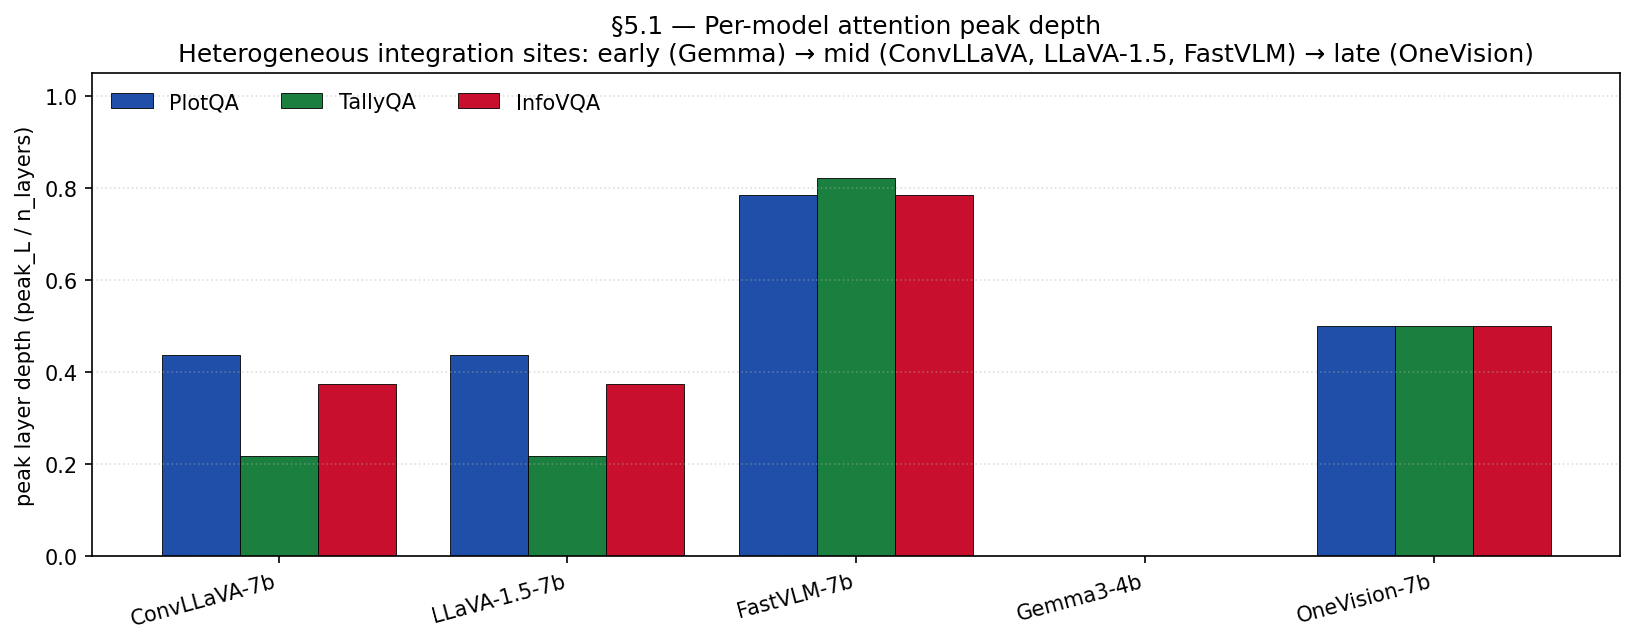

In [7]:
def fig_attention_peaks(peaks: pd.DataFrame) -> plt.Figure:
    PRETTY = {
        "convllava-7b":                "ConvLLaVA-7b",
        "llava-1.5-7b":                "LLaVA-1.5-7b",
        "fastvlm-7b":                  "FastVLM-7b",
        "gemma3-4b-it":                "Gemma3-4b",
        "llava-onevision-qwen2-7b-ov": "OneVision-7b",
    }
    df = peaks[peaks["model"].isin(PRETTY)].copy()
    # cross_dataset_peaks.csv has multiple rows per (model, dataset) — one per
    # generation step. The §5.1 figure reports the peak under the final answer
    # token alignment ("step" == "answer").
    if "step" in df.columns:
        df = df[df["step"] == "answer"].copy()
    df["depth_norm"] = df["peak_layer"] / df["n_layers"]

    fig, ax = plt.subplots(figsize=(11, 4.4), dpi=150)
    ds_order = ["plotqa", "tallyqa", "infovqa"]
    ds_color = {"plotqa": "#1F4FA8", "tallyqa": "#1A7F3F", "infovqa": "#C8102E"}
    ds_label = {"plotqa": "PlotQA", "tallyqa": "TallyQA", "infovqa": "InfoVQA"}
    model_order = list(PRETTY)
    x = np.arange(len(model_order))
    width = 0.27

    for i, ds in enumerate(ds_order):
        sub = df[df["dataset"] == ds].set_index("model").reindex(model_order)
        ys = sub["depth_norm"].values.astype(float)
        ax.bar(x + (i - 1) * width, ys, width,
               color=ds_color[ds], edgecolor="black", linewidth=0.4,
               label=ds_label[ds])

    ax.set_xticks(x)
    ax.set_xticklabels([PRETTY[m] for m in model_order], rotation=15, ha="right")
    ax.set_ylabel("peak layer depth (peak_L / n_layers)")
    ax.set_ylim(0, 1.05)
    ax.set_title("§5.1 — Per-model attention peak depth\n"
                 "Heterogeneous integration sites: early (Gemma) → mid (ConvLLaVA, LLaVA-1.5, FastVLM) → late (OneVision)")
    ax.legend(loc="upper left", frameon=False, ncol=3)
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    fig.tight_layout()
    return fig


if not peaks.empty:
    fig = fig_attention_peaks(peaks)
    save_figure(fig, "paper_5_1_attention_peak_depth")
    fig


## Summary

Pipeline: 5 model × 3 dataset attention extraction (sharded one GPU per
model) → 2-stage aggregator → `docs/insights/_data/cross_dataset_peaks.csv`
→ §5.1 figure (`paper_5_1_attention_peak_depth.{pdf,png}`).

To rerun from scratch set `RUN_INFERENCE = True` in §1 and ensure
`VLM_ANCHOR_GPUS` covers the GPUs you want pinned. The §5.3 notebook
loads the peak table from disk so it can run figure-only after this.
